# Valid-split inference viewer

Browse per-image predictions produced by `scripts/run_valid_inference.py`.

Output tree:
```
<OUT_DIR>/
  depth_npy/<stem>.npy       predicted metric depth (m)
  depth_vis/<stem>.png       colorized prediction
  comparison/<stem>.png      RGB | GT | pred@GT-scale | pred@own-scale / error / scatter
  metrics.csv                per-image AbsRel, delta<1.25, RMSE, n_valid
```

**Metric glossary**

- **AbsRel** — $\frac{1}{N}\sum \frac{|p-g|}{g}$. Mean *relative* error. Lower is better; 0.10 ≈ 10% off on average.
- **δ<1.25** — fraction of pixels where $\max(p/g, g/p) < 1.25$. % of predictions within 25% of GT. Higher is better (1.0 = perfect).
- **RMSE** — $\sqrt{\tfrac{1}{N}\sum(p-g)^2}$ in meters. Penalizes large errors more than small ones. Absolute units.

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown, HTML

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = REPO_ROOT / 'workspace' / 'valid_inference_200_epoch2'

assert OUT_DIR.is_dir(), f'not found: {OUT_DIR}'
cmp_dir = OUT_DIR / 'comparison'
vis_dir = OUT_DIR / 'depth_vis'
npy_dir = OUT_DIR / 'depth_npy'
gt_dir = REPO_ROOT / 'datasets' / 'drone_v59_depth' / 'valid' / 'depths'
rgb_dir = REPO_ROOT / 'datasets' / 'drone_v59_depth' / 'valid' / 'images'
metrics_csv = OUT_DIR / 'metrics.csv'

print(f'OUT_DIR       = {OUT_DIR}')
print(f'  comparison  : {len(list(cmp_dir.glob("*.png")))}')
print(f'  depth_vis   : {len(list(vis_dir.glob("*.png")))}')
print(f'  depth_npy   : {len(list(npy_dir.glob("*.npy")))}')

OUT_DIR       = /home/derek_austin/Depth-Anything-3/workspace/valid_inference_200_epoch2
  comparison  : 200
  depth_vis   : 200
  depth_npy   : 200


## Summary metrics

Aggregate numbers over the whole run, plus per-column distribution stats.

In [12]:
df = pd.read_csv(metrics_csv)
print(f'{len(df)} images  |  {int(df["n_valid"].sum()):,} total valid pixels evaluated\n')
summary = df[['absrel', 'delta1', 'rmse', 'n_valid']].agg(['mean', 'median', 'std', 'min', 'max'])
display(summary.round(4))

200 images  |  163,173 total valid pixels evaluated



,absrel,delta1,rmse,n_valid
mean,0.1305,0.8370,0.6137,815.8650
median,0.0933,0.9239,0.3884,804.0000
std,0.1347,0.2347,0.7350,507.1223
min,0.0356,0.0000,0.0482,49.0000
max,1.0246,0.9902,5.9980,2534.0000


## Rank by metric

Inspect best/worst predictions by any metric column.

In [13]:
SORT_BY = 'absrel'    # 'absrel' | 'delta1' | 'rmse' | 'n_valid'
ASCENDING = True      # True = best-first for absrel/rmse; flip for delta1
TOP_K = 10

df.sort_values(SORT_BY, ascending=ASCENDING).head(TOP_K).reset_index(drop=True).round(4)

,stem,absrel,delta1,rmse,n_valid
0,9da4b768-34ba-4e63-b1a9-deb62ae81e14_0051417__+0,0.0356,0.9665,0.0909,1045
1,dc4ae2c7-3ba3-4e85-ac92-f38c668d683b_000000488...,0.0382,0.9761,0.0890,1257
2,be5fd4d6-64d4-41c7-9b1c-202fc9ae1f83_0047571__+0,0.0385,0.9826,0.0830,1605
3,22d9a567-d5b4-44b0-9c01-41734817b87c_000000581...,0.0400,0.9870,0.2057,231
4,4c55180e-e248-4068-97de-e94c8c77c920_0085808__+0,0.0408,0.9687,0.2217,351
5,bc7d14ef-4368-4a27-9749-3b83cf93f82a_000000535...,0.0414,0.9794,0.0875,1556
6,8998b4ef-991d-4074-a57c-1d5f86e693df_0053528__+0,0.0419,0.9649,0.1208,940
7,5d49791b-f630-4eb1-be9c-ebcc80f5aa7b_0087077__+0,0.0428,0.9643,0.1042,729
8,22a5e371-25ca-4907-bdd1-cf79db96bfe7_000000171...,0.0461,0.9538,0.2109,692
9,fc19b29d-a3c5-4d91-856b-b6428baa995c_000000562...,0.0475,0.9889,0.3532,90


## Browse predictions

- `MODE = 'worst'`  — highest AbsRel (hardest examples)
- `MODE = 'best'`   — lowest AbsRel
- `MODE = 'random'` — random sample (reproducible via `SEED`)

The comparison PNG has six panels:

- **RGB input**
- **GT depth** — only pixels flagged valid are drawn.
- **Pred @ GT scale** — same colorbar as GT. If pred looks brighter/darker than GT in the same spot, it over/underestimates there.
- **Pred @ own scale** — colormap auto-set to pred's 2/98 percentile. Use this to see full predicted structure.
- **|pred − gt|** — absolute error, masked to valid pixels.
- **Pred-vs-GT scatter** — with a $y=x$ reference and ±25% band. Points on the diagonal are perfect; above → overestimate, below → underestimate.

AbsRel0.0796 ↓median=0.0933,δ<1.250.9314 ↑median=0.9239,RMSE (m)0.3437 ↓median=0.3884,"valid px1,064",pred range (m)0.76 → 5.72mean=2.14,GT range on valid (m)2.29 → 3.58


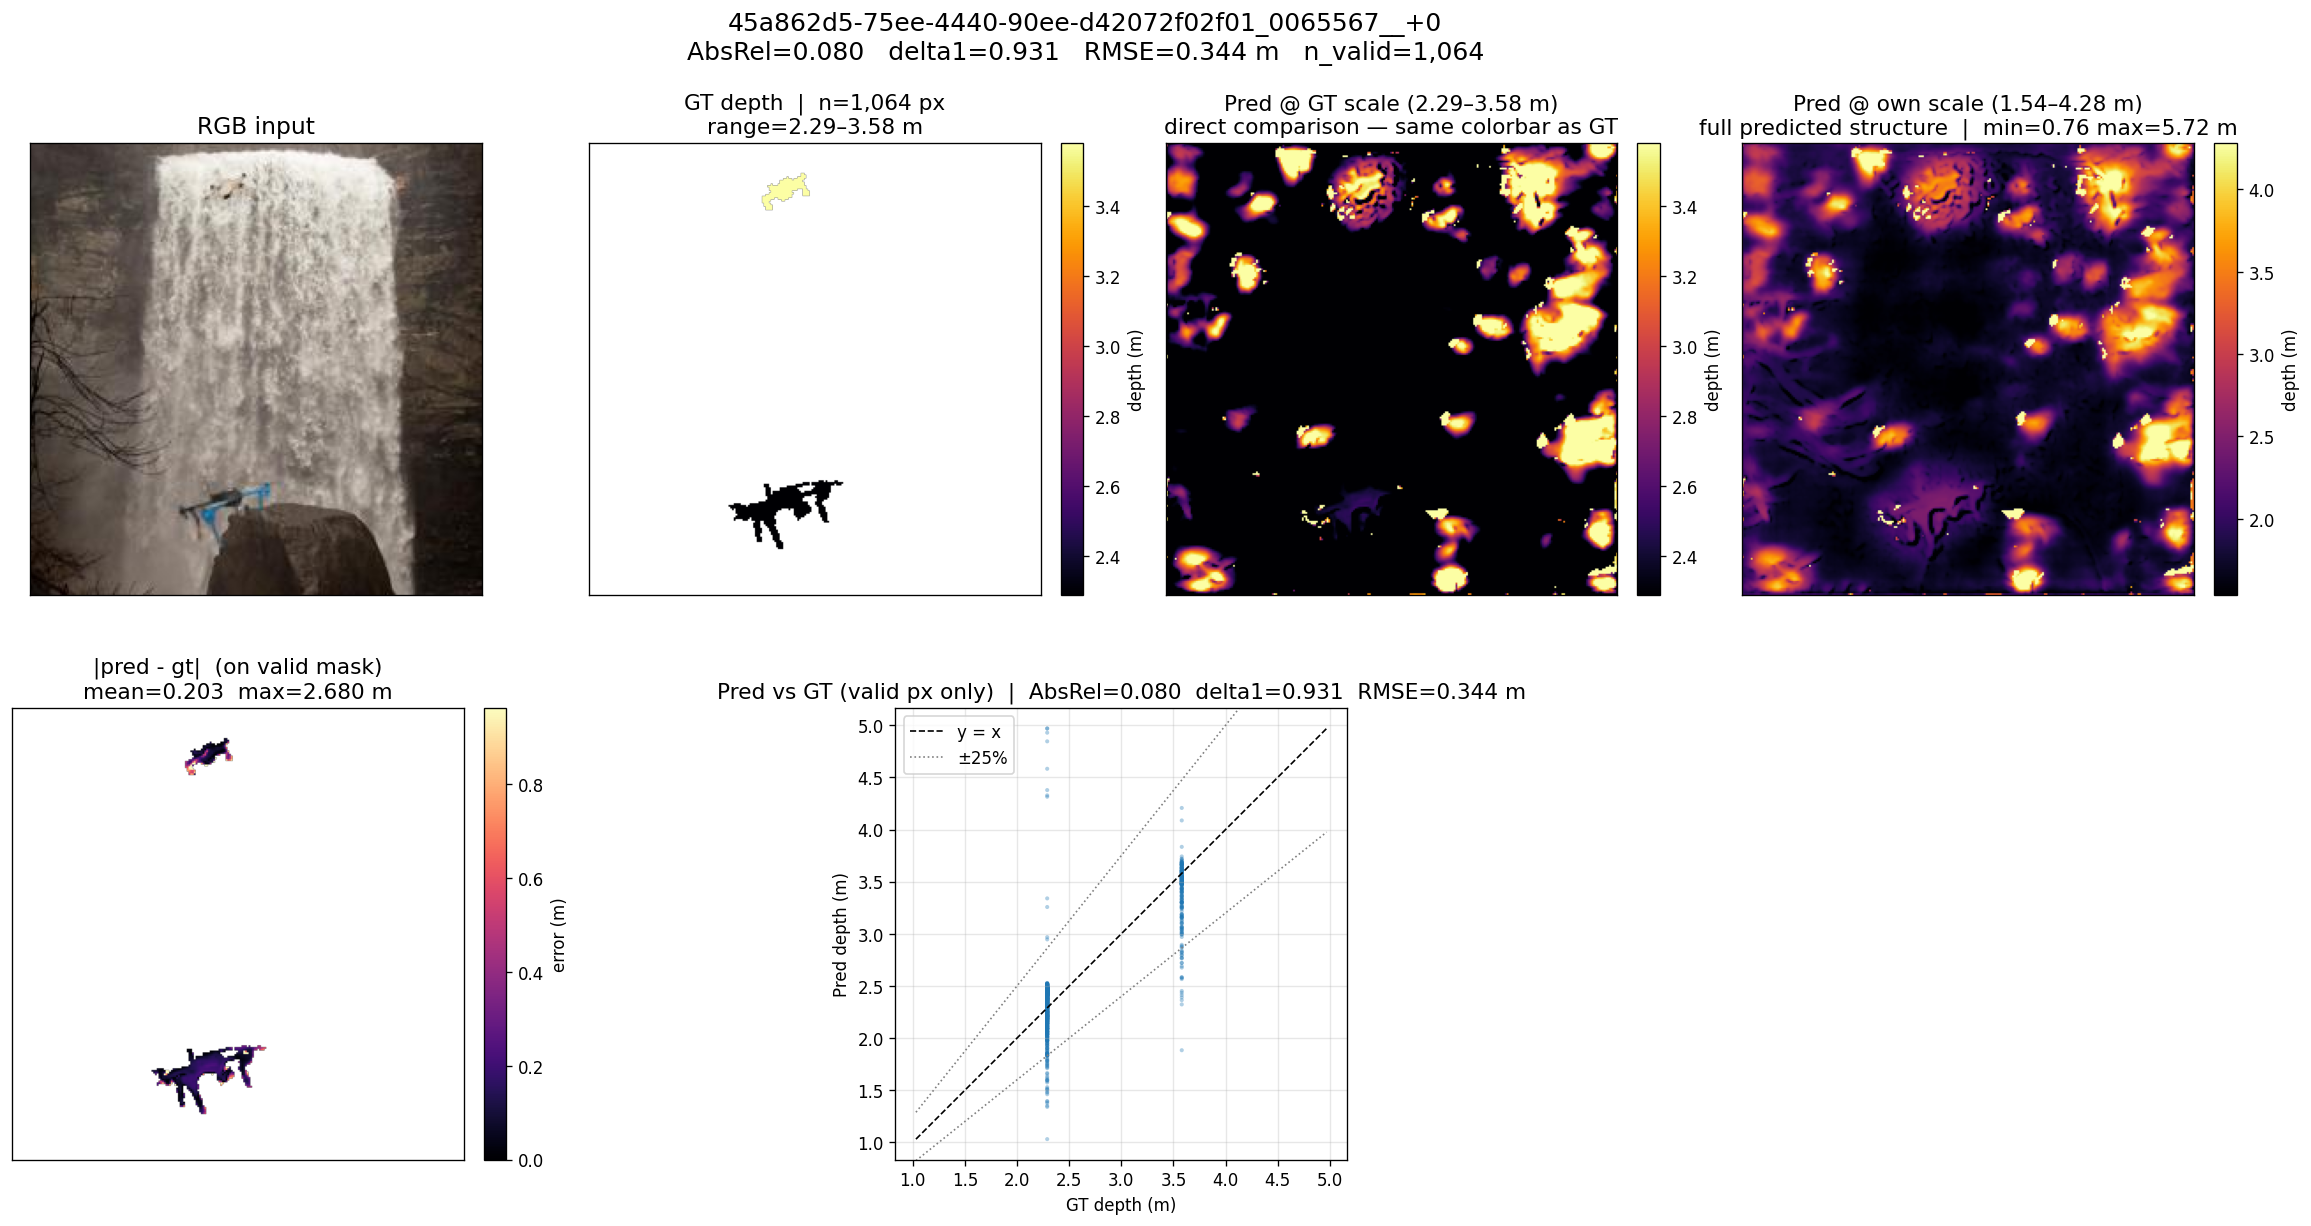

AbsRel0.1042 ↑median=0.0933,δ<1.250.9230 ↓median=0.9239,RMSE (m)0.2370 ↓median=0.3884,valid px740,pred range (m)0.37 → 6.34mean=1.73,GT range on valid (m)1.86 → 1.86


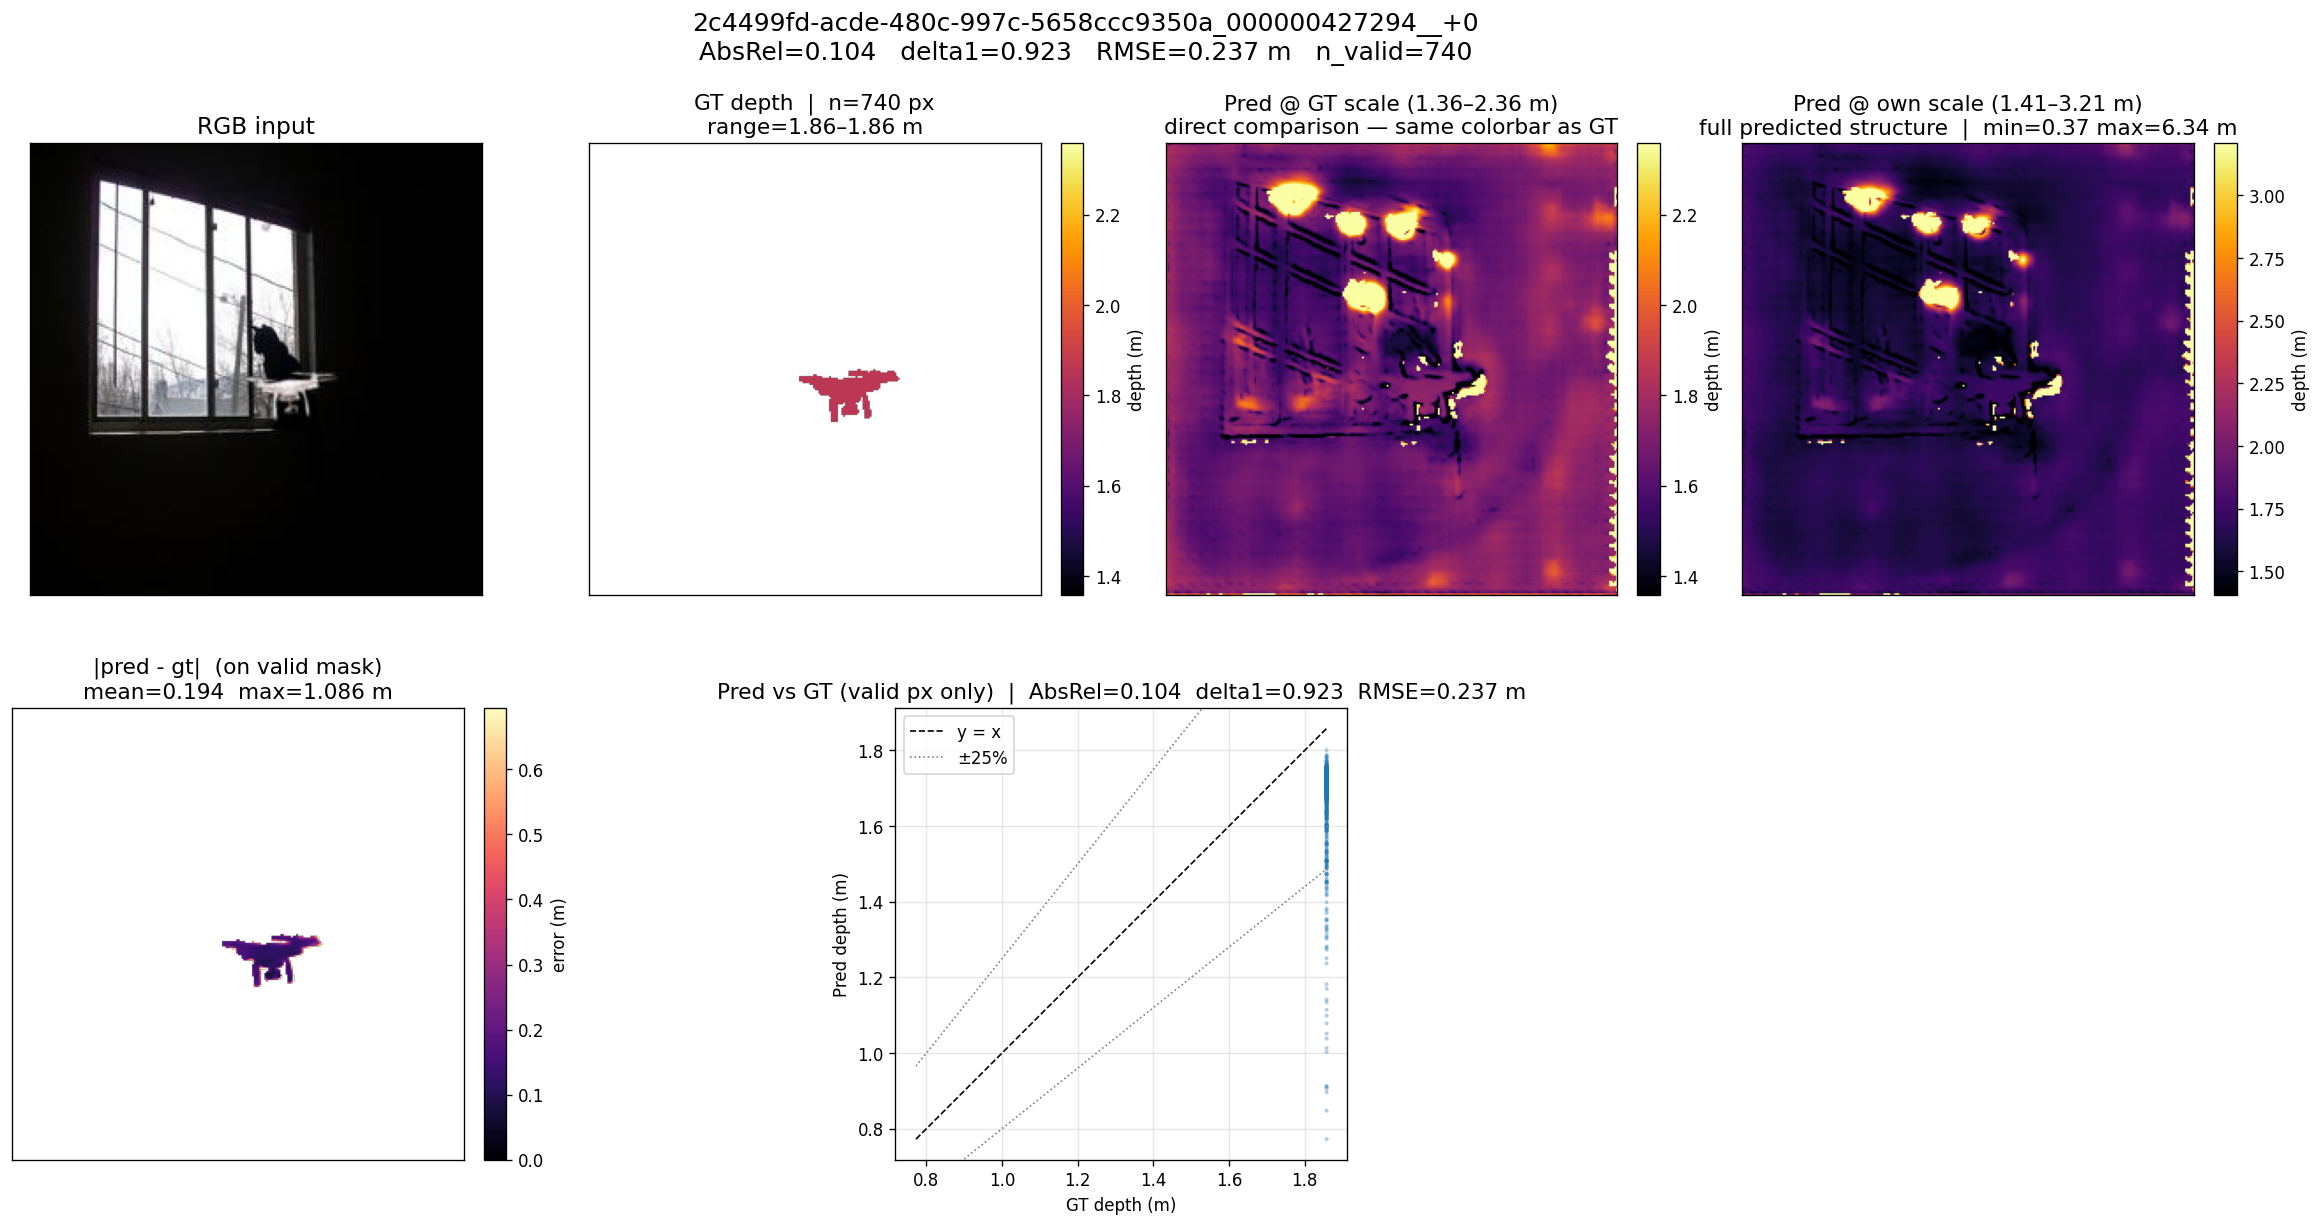

AbsRel0.2245 ↑median=0.0933,δ<1.250.4286 ↓median=0.9239,RMSE (m)1.6582 ↑median=0.3884,valid px49,pred range (m)0.84 → 6.22mean=2.18,GT range on valid (m)7.05 → 7.05


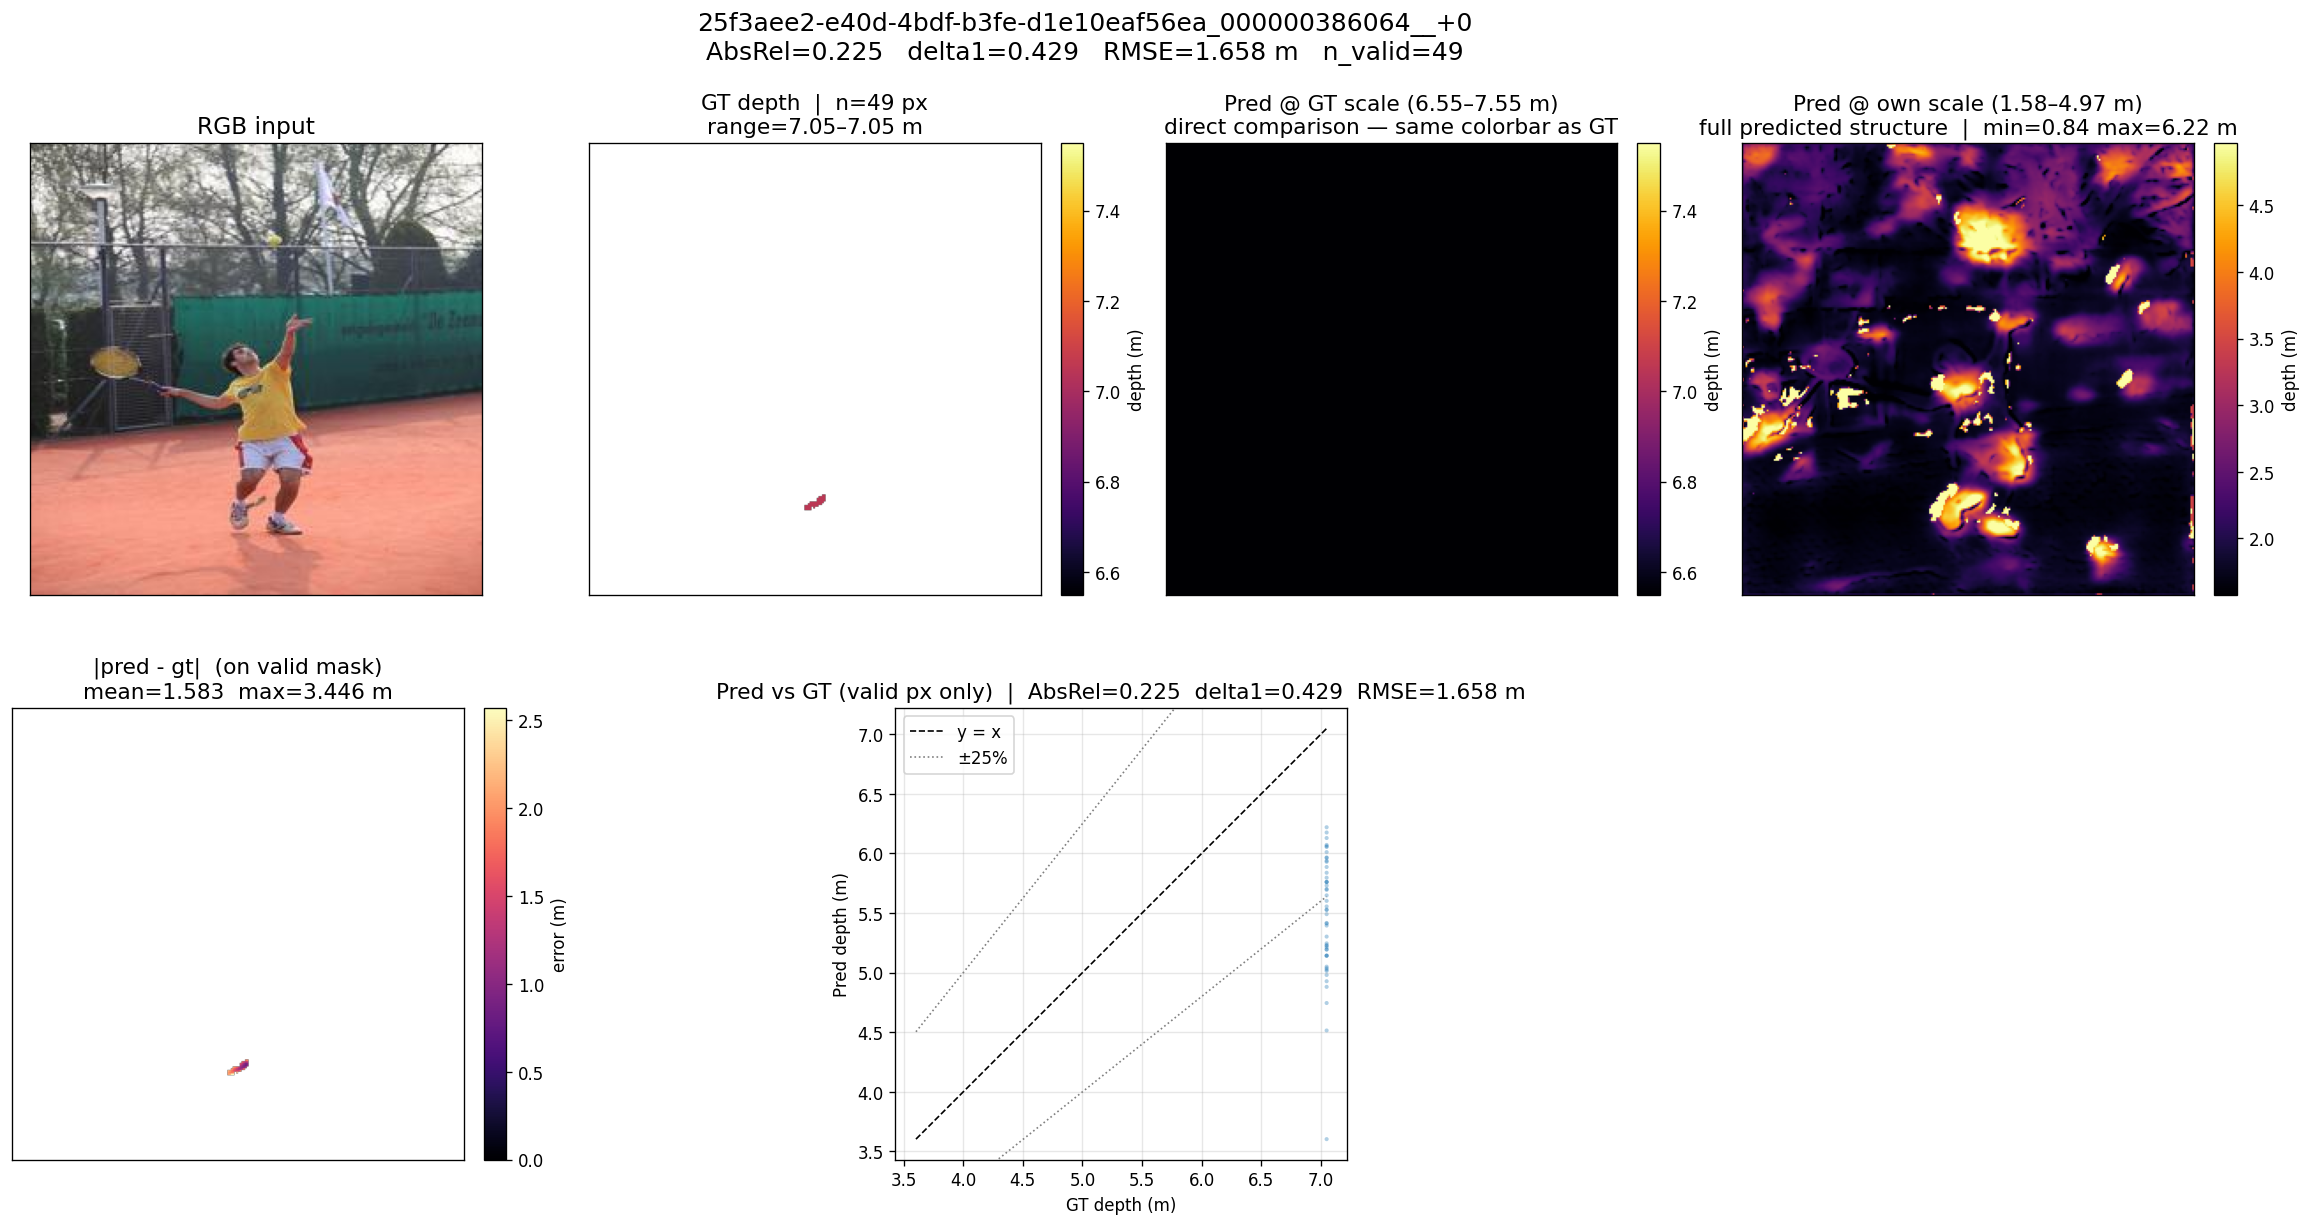

In [18]:
N_SHOW = 3
MODE = 'random'   # 'worst' | 'best' | 'random'
SEED = 1

if MODE == 'worst':
    picks = df.sort_values('absrel', ascending=False).head(N_SHOW)
elif MODE == 'best':
    picks = df.sort_values('absrel', ascending=True).head(N_SHOW)
elif MODE == 'random':
    picks = df.sample(n=min(N_SHOW, len(df)), random_state=SEED)
else:
    raise ValueError(MODE)

overall_absrel = df['absrel'].median()
overall_delta1 = df['delta1'].median()
overall_rmse = df['rmse'].median()

def _badge(val, median, higher_is_better):
    good = val >= median if higher_is_better else val <= median
    color = '#0a7d30' if good else '#b4271d'
    symbol = '&uarr;' if val > median else ('&darr;' if val < median else '=')
    return f'<span style="color:{color};font-weight:600">{val:.4f} {symbol}</span>'

for _, row in picks.iterrows():
    stem = row['stem']
    pred = np.load(npy_dir / f'{stem}.npy')
    gt = np.load(gt_dir / f'{stem}.npy').astype(np.float32)
    gt_valid = np.isfinite(gt) & (gt > 0)
    gt_range = (f'{gt[gt_valid].min():.2f} &rarr; {gt[gt_valid].max():.2f}'
                if gt_valid.any() else '&mdash;')

    display(HTML(f"<hr><h3 style='margin-bottom:4px'><code>{stem}</code></h3>"))
    display(HTML(
        '<table style="border:0;font-size:14px">'
        '<tr>'
        f'<td style="padding:4px 14px"><b>AbsRel</b><br>'
        f'{_badge(row["absrel"], overall_absrel, False)}'
        f'<br><span style="color:#777">median={overall_absrel:.4f}</span></td>'
        f'<td style="padding:4px 14px"><b>&delta;&lt;1.25</b><br>'
        f'{_badge(row["delta1"], overall_delta1, True)}'
        f'<br><span style="color:#777">median={overall_delta1:.4f}</span></td>'
        f'<td style="padding:4px 14px"><b>RMSE (m)</b><br>'
        f'{_badge(row["rmse"], overall_rmse, False)}'
        f'<br><span style="color:#777">median={overall_rmse:.4f}</span></td>'
        f'<td style="padding:4px 14px"><b>valid px</b><br>{int(row["n_valid"]):,}</td>'
        f'<td style="padding:4px 14px"><b>pred range (m)</b><br>'
        f'{pred.min():.2f} &rarr; {pred.max():.2f}'
        f'<br><span style="color:#777">mean={pred.mean():.2f}</span></td>'
        f'<td style="padding:4px 14px"><b>GT range on valid (m)</b><br>{gt_range}</td>'
        '</tr></table>'
    ))
    display(Image(filename=str(cmp_dir / f'{stem}.png'), width=1400))

## Look up a specific image

In [ ]:
# Paste a stem (filename without extension) to inspect it.
STEM = df.iloc[0]['stem']

row = df.loc[df['stem'] == STEM].squeeze()
pred = np.load(npy_dir / f'{STEM}.npy')
gt = np.load(gt_dir / f'{STEM}.npy').astype(np.float32)
gt_valid = np.isfinite(gt) & (gt > 0)

display(Markdown(
    f"### `{STEM}`\n\n"
    f"| metric | value | dataset median |\n"
    f"|---|---|---|\n"
    f"| AbsRel | **{row['absrel']:.4f}** | {df['absrel'].median():.4f} |\n"
    f"| delta<1.25 | **{row['delta1']:.4f}** | {df['delta1'].median():.4f} |\n"
    f"| RMSE | **{row['rmse']:.4f} m** | {df['rmse'].median():.4f} m |\n"
    f"| n_valid | **{int(row['n_valid']):,}** |   |\n\n"
    f"Pred depth (m): min={pred.min():.3f}  mean={pred.mean():.3f}  "
    f"median={np.median(pred):.3f}  max={pred.max():.3f}"
))
display(Image(filename=str(cmp_dir / f'{STEM}.png'), width=1400))

## Depth histograms for the image above

- **Left:** full predicted depth over every pixel in the frame.
- **Right:** pred vs GT on the valid-mask pixels only. If these two histograms are offset, the model has a systematic bias on this image.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(pred.ravel(), bins=60, color='C0', alpha=0.85)
axes[0].axvline(pred.mean(), color='k', linestyle='--', lw=1, label=f'mean={pred.mean():.2f} m')
axes[0].set_title('Predicted depth over full frame')
axes[0].set_xlabel('depth (m)')
axes[0].set_ylabel('pixel count')
axes[0].legend()
axes[0].grid(alpha=0.3)

if gt_valid.any():
    g_on_valid = gt[gt_valid]
    p_on_valid = pred[gt_valid]
    lo = float(min(g_on_valid.min(), p_on_valid.min()))
    hi = float(max(g_on_valid.max(), p_on_valid.max()))
    bins = np.linspace(lo, hi, 40)
    axes[1].hist(g_on_valid, bins=bins, color='C2', alpha=0.6, label=f'GT (n={g_on_valid.size:,})')
    axes[1].hist(p_on_valid, bins=bins, color='C3', alpha=0.6, label='Pred')
    axes[1].set_title('GT vs Pred on valid mask')
    axes[1].set_xlabel('depth (m)')
    axes[1].set_ylabel('pixel count')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
else:
    axes[1].set_title('no valid GT pixels')
fig.tight_layout()
plt.show()

## Dataset-wide metric distributions

Each panel shows the distribution of a metric across every image in the run.

- Solid vertical line = median. Dashed = mean.
- A long right tail on AbsRel/RMSE means a few images are driving up the aggregate.
- A long left tail on δ<1.25 means a few images have mostly-out-of-band predictions.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color, label in zip(
    axes,
    ['absrel', 'delta1', 'rmse'],
    ['C0', 'C2', 'C3'],
    ['AbsRel (lower better)', 'delta<1.25 (higher better)', 'RMSE meters (lower better)'],
):
    vals = df[col].dropna()
    ax.hist(vals, bins=30, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(vals.median(), color='k', linestyle='-', lw=1.2, label=f'median={vals.median():.3f}')
    ax.axvline(vals.mean(), color='k', linestyle='--', lw=1.0, label=f'mean={vals.mean():.3f}')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('# images')
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Error vs GT coverage

Does error correlate with how much of the GT is populated? Sparse labels (few valid pixels) often correspond to small/distant objects that are harder to localize.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].scatter(df['n_valid'], df['absrel'], s=14, alpha=0.55)
axes[0].set_xlabel('n_valid (GT pixels used in metric)')
axes[0].set_ylabel('AbsRel')
axes[0].set_title('AbsRel vs GT coverage')
axes[0].set_xscale('log')
axes[0].grid(alpha=0.3)

axes[1].scatter(df['n_valid'], df['rmse'], s=14, alpha=0.55, color='C3')
axes[1].set_xlabel('n_valid (GT pixels used in metric)')
axes[1].set_ylabel('RMSE (m)')
axes[1].set_title('RMSE vs GT coverage')
axes[1].set_xscale('log')
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

print('Pearson correlation with n_valid:')
for col in ['absrel', 'delta1', 'rmse']:
    r = df[[col, 'n_valid']].dropna().corr().iloc[0, 1]
    print(f'  {col:10s}: r = {r:+.3f}')